In [25]:
x = [
    [1.0, 4.0],
    [2.0, 3.5],
    [3.0, 5.0],
    [4.0, 4.5],
    [5.0, 5.0],
    [6.0, 6.0],
    [7.0, 5.5],
    [8.0, 6.5],
    [9.0, 7.0],
    [10.0, 8.0]
]
y = [
    52.0,
    55.5,
    61.0,
    64.0,
    68.0,
    74.0,
    78.0,
    83.5,
    88.0,
    94.0
]


In [26]:
def predictions(features, weight, bias):
    predicted_labels = []
    for i in range(len(features)):
        value = 0
        for j in range(len(weight)):
            value += features[i][j]*weight[j]
        value += bias
        predicted_labels.append(value)
    return predicted_labels

def calc_mse(labels, predicted_labels):
    MSE = 0
    n_samples = len(labels)
    for i in range(n_samples):
        square_error = (labels[i] - predicted_labels[i])**2
        MSE += square_error
    MSE = 1/n_samples * MSE
    return MSE

def gradient_weight(features, labels, predicted_labels, weight):
    n_samples = len(labels)
    total_grad_w = []
    for i in range(len(weight)):
        grad_w = 0
        for j in range(n_samples):
            error = predicted_labels[j]-labels[j]
            grad_w += features[j][i]* error
        grad_w = 2/n_samples * grad_w
        total_grad_w.append(grad_w)

    return total_grad_w

def gradient_bias(labels, predicted_labels):
    n_samples = len(labels)
    grad_b = 0
    for i in range(n_samples):
        error = (predicted_labels[i]-labels[i])
        grad_b += error
    grad_b = 2/n_samples * grad_b
    return grad_b

def update_weight(learning_rate, weight_gradient, weight, reg):
    new_weight = []
    for i in range(len(weight)):
        n_weight = weight[i] - learning_rate * (weight_gradient[i] + 2 * reg * weight[i])
        new_weight.append(n_weight)
    return new_weight

def update_bias(learning_rate, bias_gradient, bias):
    new_bias = bias - learning_rate * bias_gradient
    return new_bias

def Train(features, labels, weight, bias, reg,  learning_rate, epochs):
    loss_history = []
    for i in range(epochs):
        predicted_labels = predictions(features, weight, bias)
        grad_w = gradient_weight(features, labels, predicted_labels, weight)
        grad_b = gradient_bias(labels, predicted_labels)
        weight = update_weight(learning_rate, grad_w, weight, reg)
        bias = update_bias(learning_rate, grad_b, bias)
        MSE = calc_mse(labels, predicted_labels)
        # loss = MSE + reg * weight**2
        loss_history.append(MSE)
    return weight, bias, loss_history


In [27]:
w = [0,0]
b = 0
lr = 0.001
epochs = 10000
reg = 0.5

w, b, loss_history = Train(x, y, w, b, reg, lr, epochs)

print(w, b)
y_pred = predictions(x, w, b)
MSE = calc_mse(y, y_pred)
print(MSE)
print(loss_history)

[2.793242414221099, 4.957348824085714] 28.43805740825266
3.609991755536647
[5333.75, 3985.4609915840006, 2989.721537628907, 2254.1481221102845, 1710.5870703064572, 1308.75670755699, 1011.5582176134624, 791.617168857328, 628.7326678875881, 507.9959027495854, 418.4023778803116, 351.8282644451533, 302.27530343382426, 265.3137833602715, 237.6716138461619, 216.9311595084742, 201.30556031364904, 189.47368509827493, 180.45833765442922, 173.53637097340825, 168.17234203197077, 163.9695349904215, 160.63379994460786, 157.94684868622153, 155.74652982378822, 153.91225536439208, 152.35423012272108, 151.00548885292773, 149.81600678868543, 148.7483416645864, 147.7744072267071, 146.87308295974262, 146.0284420262074, 145.22843643103874, 144.46392050400024, 143.72792485023163, 143.01511584591702, 142.32139268292903, 141.643586465884, 140.9792350973109, 140.32641450735096, 139.6836118249814, 139.0496298140308, 138.42351465303724, 137.80450117694667, 137.19197120804623, 136.5854217215617, 135.9844404201032

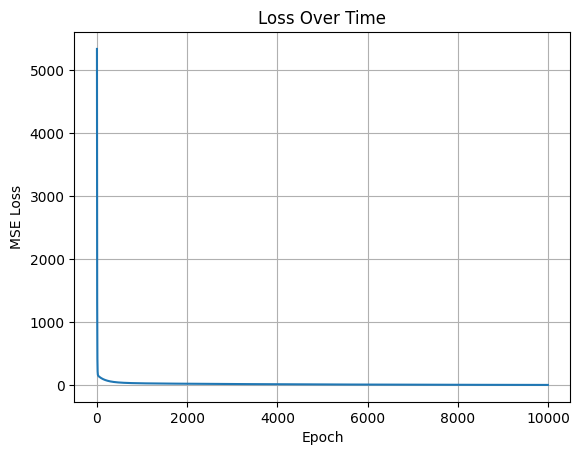

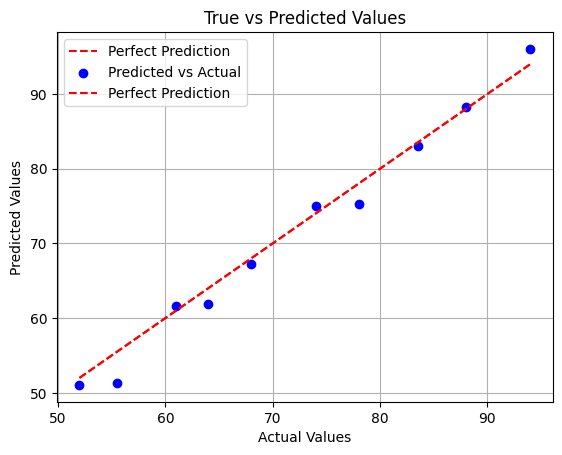

In [28]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Over Time")
plt.grid(True)
plt.show()

y_pred = predictions(x, w, b)
import numpy as np

plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', label='Perfect Prediction')


y_np = np.array(y)
y_pred_np = np.array(y_pred)

plt.scatter(y_np, y_pred_np, color='blue', label='Predicted vs Actual')
plt.plot([y_np.min(), y_np.max()], [y_np.min(), y_np.max()], 'r--', label='Perfect Prediction')


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

